# Week 4 — Logistic Regression and Feature Scaling (Classification)

**Two datasets, one analysis.** This notebook loads the **Credit Risk** (Kaggle, ~29k applications) and
**Statlog German Credit** (UCI, 1,000 applications) datasets together and applies every Week 4
technique to **both**, with matching visualizations, so the two can be compared head to head.
Credit Risk predicts **default**; German Credit predicts **bad credit**. Both targets are imbalanced.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
sns.set_style('whitegrid'); plt.rcParams['figure.figsize']=(11,4); pd.set_option('display.max_columns',60)
RANDOM_STATE = 42
DATASETS = ['Credit Risk', 'German Credit']
PALETTE = {'Credit Risk':'#4c72b0', 'German Credit':'#55a467'}

# ---------- Credit Risk ----------
def _credit_risk():
    df = pd.read_csv('credit_risk_dataset.csv')
    df = df.dropna(subset=['loan_int_rate']).reset_index(drop=True)
    df = df[df['person_age'] <= 80]
    df = df[df['person_emp_length'].fillna(0) <= 60]
    df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
    df['loan_grade_ord'] = df['loan_grade'].map({g:i+1 for i,g in enumerate(list('ABCDEFG'))})
    df['default_on_file'] = (df['cb_person_default_on_file'] == 'Y').astype(int)
    df['log_income'] = np.log(df['person_income'])
    df = pd.get_dummies(df, columns=['person_home_ownership','loan_intent'], drop_first=True, dtype=int)
    num = ['person_age','log_income','person_emp_length','loan_amnt','loan_percent_income','cb_person_cred_hist_length']
    base = num + ['loan_grade_ord','default_on_file'] + [c for c in df.columns if c.startswith('person_home_ownership_') or c.startswith('loan_intent_')]
    return dict(df=df, num=num, poly=['person_age','loan_amnt','cb_person_cred_hist_length'],
                reg_target='loan_int_rate', reg_label='interest rate (%)', reg_feats=base,
                clf_target='loan_status', clf_pos='default', clf_feats=base+['loan_int_rate'])

# ---------- German Credit ----------
def _german():
    rename={'Attribute1':'checking_status','Attribute2':'duration_months','Attribute3':'credit_history',
     'Attribute4':'purpose','Attribute5':'credit_amount','Attribute6':'savings_status','Attribute7':'employment_since',
     'Attribute8':'installment_rate','Attribute9':'personal_status_sex','Attribute10':'other_debtors',
     'Attribute11':'residence_since','Attribute12':'property','Attribute13':'age_years','Attribute14':'other_installment_plans',
     'Attribute15':'housing','Attribute16':'existing_credits','Attribute17':'job','Attribute18':'num_dependents',
     'Attribute19':'telephone','Attribute20':'foreign_worker','class':'target'}
    df = pd.read_csv('german_credit_data.csv').rename(columns=rename)
    df['bad'] = (df['target'] == 2).astype(int); df = df.drop(columns=['target'])
    df['log_credit_amount'] = np.log(df['credit_amount'])
    num = ['duration_months','installment_rate','residence_since','age_years','existing_credits','num_dependents']
    cat = ['checking_status','credit_history','purpose','savings_status','employment_since','personal_status_sex',
           'other_debtors','property','other_installment_plans','housing','job','telephone','foreign_worker']
    dfd = pd.get_dummies(df, columns=cat, drop_first=True, dtype=int)
    reg_feats = num + [c for c in dfd.columns if any(c.startswith(p+'_') for p in cat)] + ['bad']
    clf_feats = num + ['credit_amount'] + [c for c in dfd.columns if any(c.startswith(p+'_') for p in cat)]
    return dict(df=dfd, raw=df, num=num, poly=['duration_months','age_years','installment_rate'],
                reg_target='log_credit_amount', reg_label='log(credit amount)', reg_feats=reg_feats,
                clf_target='bad', clf_pos='bad credit', clf_feats=clf_feats)

_CACHE = {'Credit Risk':_credit_risk(), 'German Credit':_german()}

def reg_design(name):
    c=_CACHE[name]; X=c['df'][c['reg_feats']].astype(float); y=c['df'][c['reg_target']].astype(float)
    Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=RANDOM_STATE)
    return dict(name=name, Xtr=Xtr,Xte=Xte,ytr=ytr,yte=yte, num=c['num'], poly=c['poly'],
                target=c['reg_target'], label=c['reg_label'], df=c['df'])

def clf_design(name):
    c=_CACHE[name]; X=c['df'][c['clf_feats']].astype(float); y=c['df'][c['clf_target']].astype(int)
    Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=RANDOM_STATE,stratify=y)
    return dict(name=name, Xtr=Xtr,Xte=Xte,ytr=ytr,yte=yte, num=c['num'], pos=c['clf_pos'],
                target=c['clf_target'], df=c['df'])

def rmse(a,b): return float(np.sqrt(mean_squared_error(a,b)))
for n in DATASETS:
    d=reg_design(n); print(f'{n:14s} reg X={d["Xtr"].shape[1]} feats, target={d["target"]}')
    c=clf_design(n); print(f'{n:14s} clf X={c["Xtr"].shape[1]} feats, pos rate={c["ytr"].mean():.3f}')

Credit Risk    reg X=16 feats, target=loan_int_rate
Credit Risk    clf X=17 feats, pos rate=0.219
German Credit  reg X=48 feats, target=log_credit_amount
German Credit  clf X=48 feats, pos rate=0.300


## 1 · Why ordinary linear regression fails on a binary target

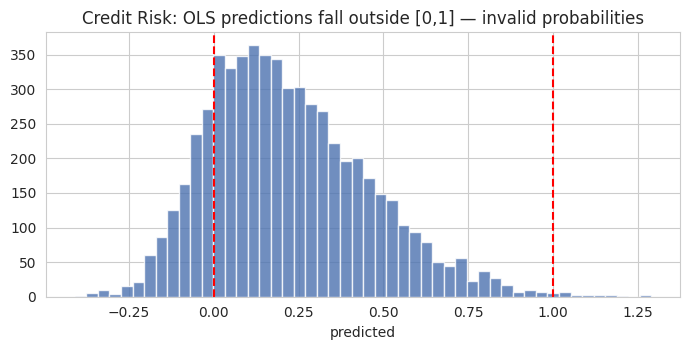

Credit Risk: 17.2% below 0, 0.4% above 1


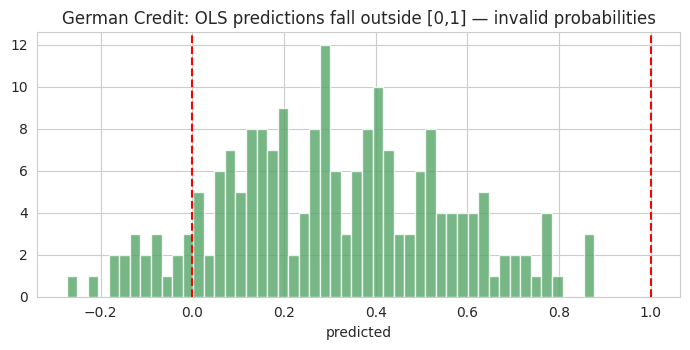

German Credit: 10.0% below 0, 0.0% above 1


In [2]:
for name in DATASETS:
    d = clf_design(name)
    yhat = Pipeline([('sc',StandardScaler()),('lr',LinearRegression())]).fit(d['Xtr'],d['ytr']).predict(d['Xte'])
    plt.figure(figsize=(7,3.6)); plt.hist(yhat,bins=50,color=PALETTE[name],alpha=.8)
    plt.axvline(0,color='red',ls='--'); plt.axvline(1,color='red',ls='--')
    plt.title(f'{name}: OLS predictions fall outside [0,1] — invalid probabilities'); plt.xlabel('predicted'); plt.tight_layout(); plt.show()
    print(f'{name}: {(yhat<0).mean():.1%} below 0, {(yhat>1).mean():.1%} above 1')

## 2 · Feature scaling — coefficient magnitudes, unscaled vs standardized

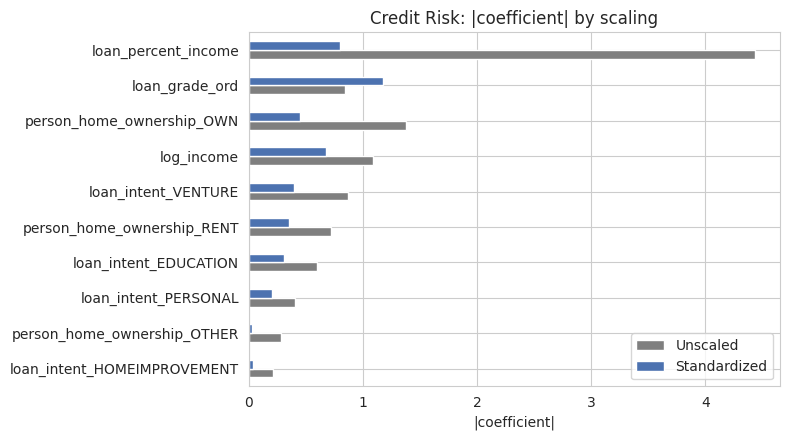

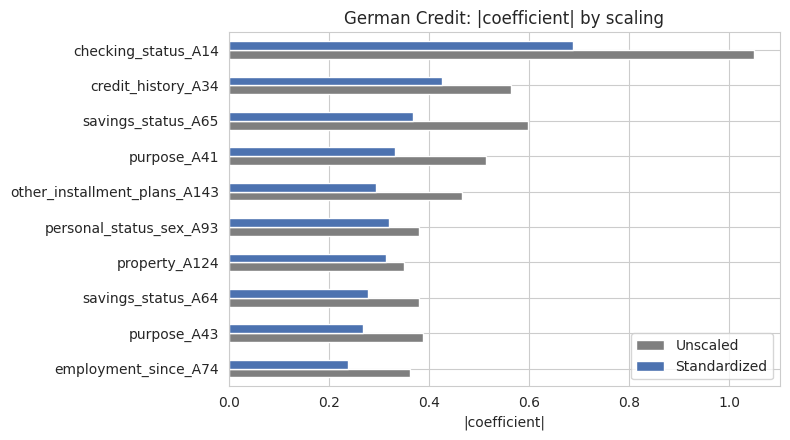

In [3]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
for name in DATASETS:
    d = clf_design(name)
    uns = LogisticRegression(penalty='l2',C=0.1,max_iter=5000,random_state=RANDOM_STATE).fit(d['Xtr'],d['ytr'])
    std = Pipeline([('sc',StandardScaler()),('lr',LogisticRegression(penalty='l2',C=0.1,max_iter=5000,random_state=RANDOM_STATE))]).fit(d['Xtr'],d['ytr'])
    comp = pd.DataFrame({'Unscaled':uns.coef_.ravel(),'Standardized':std.named_steps['lr'].coef_.ravel()}, index=d['Xtr'].columns)
    top = comp.abs().sum(axis=1).sort_values(ascending=False).head(10).index
    comp.loc[top][::-1].abs().plot(kind='barh',figsize=(8,4.5),color=['#7f7f7f','#4c72b0']); plt.title(f'{name}: |coefficient| by scaling'); plt.xlabel('|coefficient|'); plt.tight_layout(); plt.show()

## 3 · Regularized logistic regression — tune C by CV (L1 and L2)

In [4]:
LOG = {}
for name in DATASETS:
    d = clf_design(name); Cs=np.logspace(-3,3,13)
    l1=Pipeline([('sc',StandardScaler()),('lr',LogisticRegressionCV(Cs=Cs,cv=5,penalty='l1',solver='saga',scoring='roc_auc',max_iter=6000,random_state=RANDOM_STATE,n_jobs=-1))]).fit(d['Xtr'],d['ytr'])
    l2=Pipeline([('sc',StandardScaler()),('lr',LogisticRegressionCV(Cs=Cs,cv=5,penalty='l2',scoring='roc_auc',max_iter=6000,random_state=RANDOM_STATE,n_jobs=-1))]).fit(d['Xtr'],d['ytr'])
    LOG[name]=dict(d=d,l1=l1,l2=l2)
    print(f"{name}: L1 best C={l1.named_steps['lr'].C_[0]:.3g} (zeroed {int(np.sum(np.abs(l1.named_steps['lr'].coef_.ravel())<1e-8))}/{d['Xtr'].shape[1]}) | L2 best C={l2.named_steps['lr'].C_[0]:.3g}")

Credit Risk: L1 best C=0.1 (zeroed 1/17) | L2 best C=0.1


German Credit: L1 best C=0.316 (zeroed 7/48) | L2 best C=0.1


## 4 · Evaluation — ROC and confusion matrix (regularized L2 model)

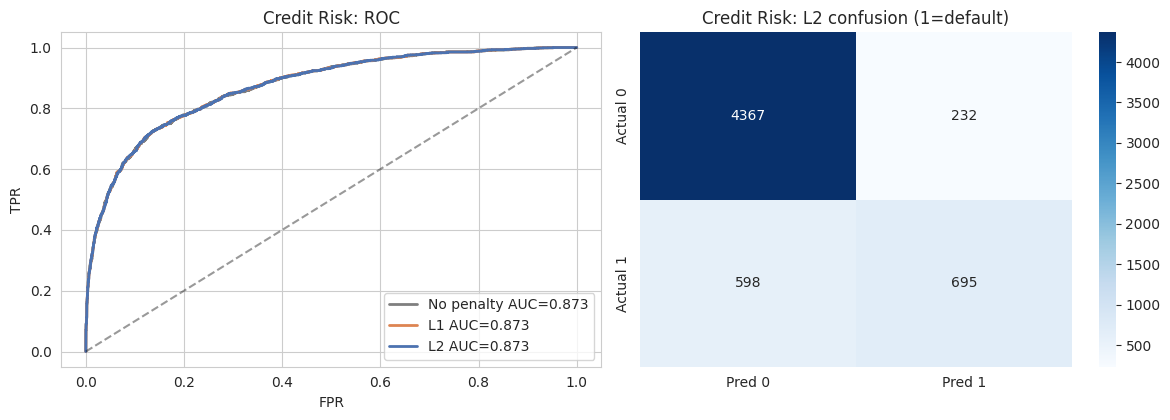

=== Credit Risk ===
               precision    recall  f1-score   support

           0      0.880     0.950     0.913      4599
           1      0.750     0.538     0.626      1293

    accuracy                          0.859      5892
   macro avg      0.815     0.744     0.770      5892
weighted avg      0.851     0.859     0.850      5892



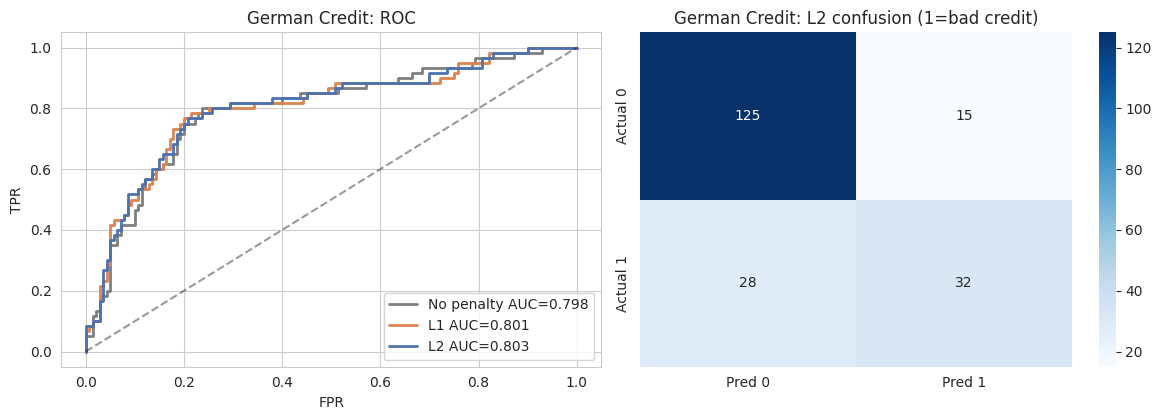

=== German Credit ===
               precision    recall  f1-score   support

           0      0.817     0.893     0.853       140
           1      0.681     0.533     0.598        60

    accuracy                          0.785       200
   macro avg      0.749     0.713     0.726       200
weighted avg      0.776     0.785     0.777       200



In [5]:
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report, f1_score
CLF_RES={n:[] for n in DATASETS}
for name in DATASETS:
    d=LOG[name]['d']; l1=LOG[name]['l1']; l2=LOG[name]['l2']
    nopen=LogisticRegression(penalty=None,max_iter=5000).fit(d['Xtr'],d['ytr'])
    fig,ax=plt.subplots(1,2,figsize=(12,4.3))
    for lbl,m,c in [('No penalty',nopen,'#7f7f7f'),('L1',l1,'#dd8452'),('L2',l2,'#4c72b0')]:
        p=m.predict_proba(d['Xte'])[:,1]; fpr,tpr,_=roc_curve(d['yte'],p); ax[0].plot(fpr,tpr,label=f'{lbl} AUC={roc_auc_score(d["yte"],p):.3f}',lw=2,color=c)
    ax[0].plot([0,1],[0,1],'k--',alpha=.4); ax[0].set_title(f'{name}: ROC'); ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR'); ax[0].legend()
    bp=l2.predict_proba(d['Xte'])[:,1]; pred=(bp>=.5).astype(int)
    sns.heatmap(confusion_matrix(d['yte'],pred),annot=True,fmt='d',cmap='Blues',ax=ax[1],
                xticklabels=['Pred 0','Pred 1'],yticklabels=['Actual 0','Actual 1']); ax[1].set_title(f'{name}: L2 confusion (1={d["pos"]})')
    plt.tight_layout(); plt.show()
    for lbl,m in [('Logistic no-penalty',nopen),('Logistic L1',l1),('Logistic L2',l2)]:
        p=m.predict_proba(d['Xte'])[:,1]; pr=(p>=.5).astype(int)
        CLF_RES[name].append({'model':lbl,'AUC':round(roc_auc_score(d['yte'],p),4),'F1':round(f1_score(d['yte'],pr),4)})
    print(f'=== {name} ===\n', classification_report(d['yte'],pred, digits=3))

## 5 · Conclusions

Both targets are imbalanced (Credit Risk ~22% default, German 30% bad), so accuracy is misleading and I lead
with **AUC and F1**. On **Credit Risk** the regularized logistic model reaches test AUC ≈ 0.873 with recall
~0.54 on defaulters; on **German Credit** it reaches AUC ≈ 0.803 with recall ~0.53 on bad credit. Standardizing
makes the penalty fall fairly across features (visible in the coefficient plots), and L1 prunes uninformative
dummies without hurting AUC. As later weeks show, this simple model is **the best classifier on German**, while
on Credit Risk it is clearly beaten by the random forest — model superiority depends on the data.